# Random vs UCB Stochastic Approximation — Binary MNIST

Compare `StochasticApproximation` (pure random search) against `StochasticApproximationUCBDynamic` (UCB over an adaptive binary partition) on `ReLUNet`s trained as binary MNIST classifiers (e.g. digits 1 vs 7).

Pipeline per architecture:
1. Train the network as a binary MNIST classifier on `DIGITS`.
2. Run both methods across `N_SEEDS` repeats with the full `COMPARE_ITERS` budget — no early stop, no ground-truth reference.
3. Plot mean ± std convergence bands vs iterations and vs wall-clock time.

Domain: `[0, 1]^784` (matches MNIST pixel range). `c_vector = [1, -1]` projects onto the difference of the two class logits.

In [17]:
import sys, time
sys.path.append('..')

import numpy as np
import torch
import matplotlib.pyplot as plt

from relu_nets import ReLUNet
from hyperbox import Hyperbox
from other_methods import StochasticApproximation, StochasticApproximationUCBDynamic
import neural_nets.data_loaders as data_loaders
import neural_nets.train as train

## Config — edit this cell

Each entry in `ARCHITECTURES` must start with `784` (MNIST input dim) and end with `2` (binary output).

In [18]:
INPUT_DIM     = 784
OUTPUT_DIM    = 2
DIGITS        = [1, 7]   # binary classification target
DATASET_DIR   = '../datasets'   # MNIST raw files live at LipSSA/datasets/MNIST/raw/

ARCHITECTURES = [
    # [INPUT_DIM, 4,           OUTPUT_DIM],
    # [INPUT_DIM, 16, 16,      OUTPUT_DIM],
    [INPUT_DIM, 32, 32,      OUTPUT_DIM],
    [INPUT_DIM, 64, 64, 64,  OUTPUT_DIM],
    [INPUT_DIM, 32, 32, 32, 32, OUTPUT_DIM],
]

PRIMAL_NORM   = 'linf'

TRAIN_EPOCHS  = 5
TRAIN_LR      = 1e-3
TRAIN_BATCH   = 64
TRAIN_SEED    = 0

COMPARE_ITERS = 500_000
N_SEEDS       = 5
SEEDS         = list(range(N_SEEDS))

UCB_C         = 5
UCB_PARTITION = 2

## Helpers

Two thin subclasses mirror the original solver loops (`other_methods/stochastic_approximation.py:30-60`, `other_methods/stochastic_approximation_ucb_dynamic.py:308-345`) and add per-iteration history (best-so-far value + wall time).

In [19]:
def train_mnist_network(arch, digits, epochs, lr, batch_size, seed=0, dataset_dir='../datasets'):
    torch.manual_seed(seed); np.random.seed(seed)
    net = ReLUNet(arch)
    mnist_train = data_loaders.load_mnist_data('train', digits=digits, batch_size=batch_size,
                                               shuffle=True, dataset_dir=dataset_dir)
    mnist_val   = data_loaders.load_mnist_data('val',   digits=digits, batch_size=batch_size,
                                               shuffle=True, dataset_dir=dataset_dir)
    train_params = train.TrainParameters(
        mnist_train, mnist_val, epochs,
        test_after_epoch=1,
        optimizer=torch.optim.Adam(net.parameters(), lr=lr),
    )
    train.training_loop(net, train_params)
    return net


class RandomSAHist(StochasticApproximation):
    def compute(self, max_iter=10000, **_):
        self.history_value = np.empty(max_iter, dtype=np.float64)
        self.history_time  = np.empty(max_iter, dtype=np.float64)
        self.iteration_count = 0
        random_pts = self.domain.random_point(num_points=max_iter, requires_grad=False)
        random_pts = random_pts.to(self.DEVICE).detach().requires_grad_(True)
        t0 = time.perf_counter()
        for it in range(max_iter):
            fx = self.f(random_pts[it])
            if self.value < fx:
                self.value = torch.maximum(self.value, fx)
            self.iteration_count += 1
            self.history_value[it] = float(self.value)
            self.history_time[it]  = time.perf_counter() - t0
        self.compute_time = float(self.history_time[-1])
        return self.value.cpu().detach().numpy().squeeze()


class UCBSAHist(StochasticApproximationUCBDynamic):
    def compute(self, max_iter=1000, **_):
        self.history_value = np.empty(max_iter, dtype=np.float64)
        self.history_time  = np.empty(max_iter, dtype=np.float64)
        self.iteration_count = 0
        next_partition = self.partition_step
        step_mul = self.partition_step
        self.space.max_iter = max_iter
        t0 = time.perf_counter()
        for it in range(max_iter):
            if it == next_partition:
                self.space.increment()
                next_partition = next_partition * step_mul
            reg = self.space.choose_region()
            x = reg.get_random_points(1)
            fx = self.f(x)
            fx_scalar = float(fx.detach().cpu().item())
            x_np = x.detach().cpu().numpy().reshape(-1)[:self.space.dimension]
            self.space.add_evaluation(x_np, fx_scalar)
            if self.value < fx:
                self.value = torch.maximum(self.value, fx)
                self.answer_coords = x.detach().cpu().numpy()
            self.iteration_count += 1
            self.history_value[it] = float(self.value)
            self.history_time[it]  = time.perf_counter() - t0
        self.compute_time = float(self.history_time[-1])
        return self.value


def aggregate_iter(histories):
    arr = np.stack(histories, axis=0)
    return arr.mean(axis=0), arr.std(axis=0)


def aggregate_time(value_hists, time_hists, n_grid=200):
    t_max = min(t[-1] for t in time_hists)
    grid = np.linspace(0.0, t_max, n_grid)
    interp = np.stack([np.interp(grid, t, v) for t, v in zip(time_hists, value_hists)], axis=0)
    return grid, interp.mean(axis=0), interp.std(axis=0)

## Run the experiment

In [20]:
domain   = Hyperbox.build_unit_hypercube(INPUT_DIM)
c_vector = torch.tensor([1.0, -1.0])

results = {}
for arch in ARCHITECTURES:
    assert arch[0] == INPUT_DIM and arch[-1] == OUTPUT_DIM, \
        f'Architecture must start with {INPUT_DIM} and end with {OUTPUT_DIM}: got {arch}'
    print(f'=== {arch} ===')
    net = train_mnist_network(arch, DIGITS, TRAIN_EPOCHS, TRAIN_LR, TRAIN_BATCH,
                              seed=TRAIN_SEED, dataset_dir=DATASET_DIR)

    rand_v_hist, rand_t_hist = [], []
    ucb_v_hist,  ucb_t_hist  = [], []
    for seed in SEEDS:
        torch.manual_seed(seed); np.random.seed(seed)
        rand = RandomSAHist(net, c_vector, domain, primal_norm=PRIMAL_NORM)
        rand.compute(max_iter=COMPARE_ITERS)
        rand_v_hist.append(rand.history_value)
        rand_t_hist.append(rand.history_time)

        torch.manual_seed(seed); np.random.seed(seed)
        ucb = UCBSAHist(net, c_vector, domain, c=UCB_C,
                        partition_step=UCB_PARTITION, primal_norm=PRIMAL_NORM)
        ucb.compute(max_iter=COMPARE_ITERS)
        ucb_v_hist.append(ucb.history_value)
        ucb_t_hist.append(ucb.history_time)

        print(f'  seed {seed}: rand={rand.history_value[-1]:.4f} ({rand.compute_time:.2f}s)  '
              f'ucb={ucb.history_value[-1]:.4f} ({ucb.compute_time:.2f}s)')

    rand_iter_mean, rand_iter_std = aggregate_iter(rand_v_hist)
    ucb_iter_mean,  ucb_iter_std  = aggregate_iter(ucb_v_hist)
    rand_tg, rand_tm, rand_ts = aggregate_time(rand_v_hist, rand_t_hist)
    ucb_tg,  ucb_tm,  ucb_ts  = aggregate_time(ucb_v_hist,  ucb_t_hist)

    results[tuple(arch)] = dict(
        rand=dict(iter_mean=rand_iter_mean, iter_std=rand_iter_std,
                  time_grid=rand_tg, time_mean=rand_tm, time_std=rand_ts,
                  v_hist=rand_v_hist, t_hist=rand_t_hist),
        ucb=dict(iter_mean=ucb_iter_mean, iter_std=ucb_iter_std,
                 time_grid=ucb_tg, time_mean=ucb_tm, time_std=ucb_ts,
                 v_hist=ucb_v_hist, t_hist=ucb_t_hist),
    )

=== [784, 32, 32, 2] ===
Epoch 00 | Accuracy: 99.55
Epoch 01 | Accuracy: 99.60
Epoch 02 | Accuracy: 99.69
Epoch 03 | Accuracy: 99.75
Epoch 04 | Accuracy: 99.78
Epoch 05 | Accuracy: 99.80
  seed 0: rand=314.7088 (37.13s)  ucb=314.7088 (90.19s)
  seed 1: rand=314.7088 (37.18s)  ucb=314.7088 (92.27s)
  seed 2: rand=314.7088 (37.08s)  ucb=314.7088 (90.82s)
  seed 3: rand=298.9506 (37.41s)  ucb=314.7088 (86.29s)
  seed 4: rand=314.7088 (36.88s)  ucb=314.7088 (88.03s)
=== [784, 64, 64, 64, 2] ===
Epoch 00 | Accuracy: 99.61
Epoch 01 | Accuracy: 99.03
Epoch 02 | Accuracy: 99.55
Epoch 03 | Accuracy: 99.70
Epoch 04 | Accuracy: 99.81
Epoch 05 | Accuracy: 99.75
  seed 0: rand=256.5062 (44.13s)  ucb=251.0358 (91.06s)
  seed 1: rand=275.9274 (44.05s)  ucb=266.5452 (99.15s)
  seed 2: rand=236.8676 (44.13s)  ucb=272.1309 (93.09s)
  seed 3: rand=236.8676 (43.89s)  ucb=247.5898 (97.20s)
  seed 4: rand=289.6384 (43.85s)  ucb=289.6384 (97.09s)
=== [784, 32, 32, 32, 32, 2] ===
Epoch 00 | Accuracy: 99.63
Ep

## Convergence — mean ± std vs iterations and vs time

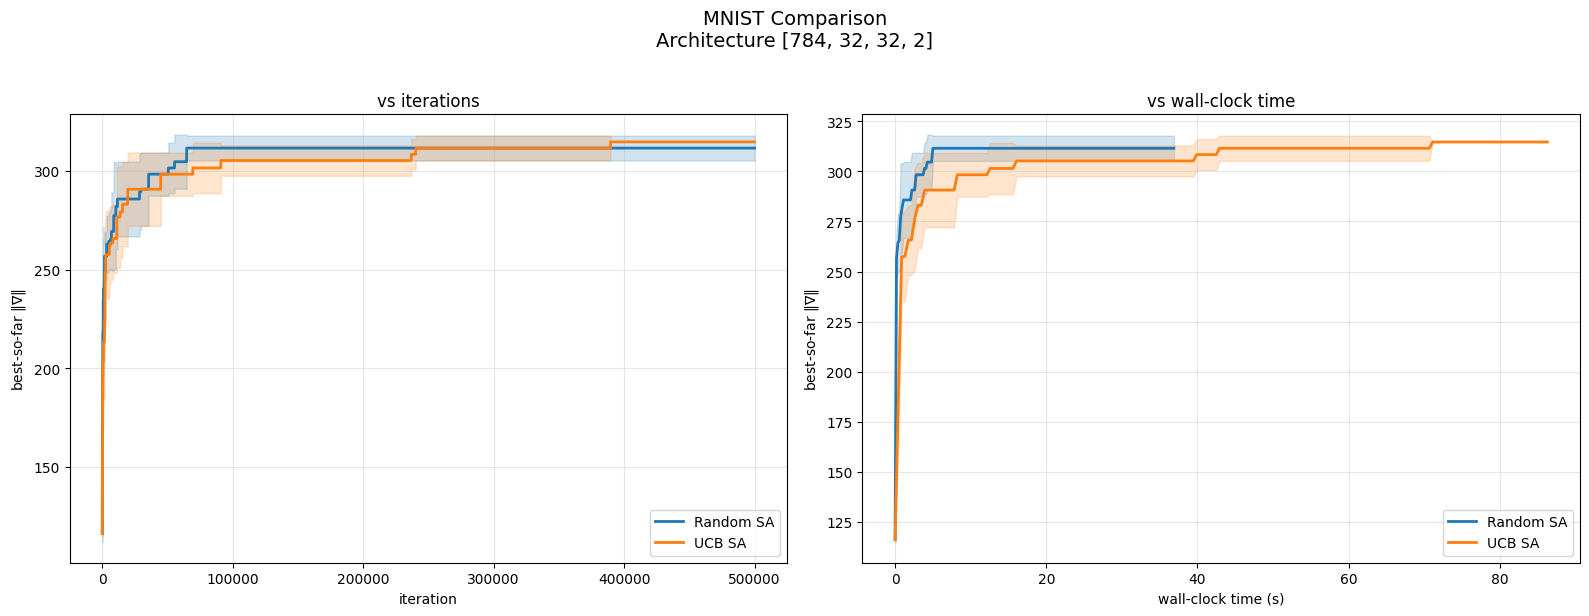

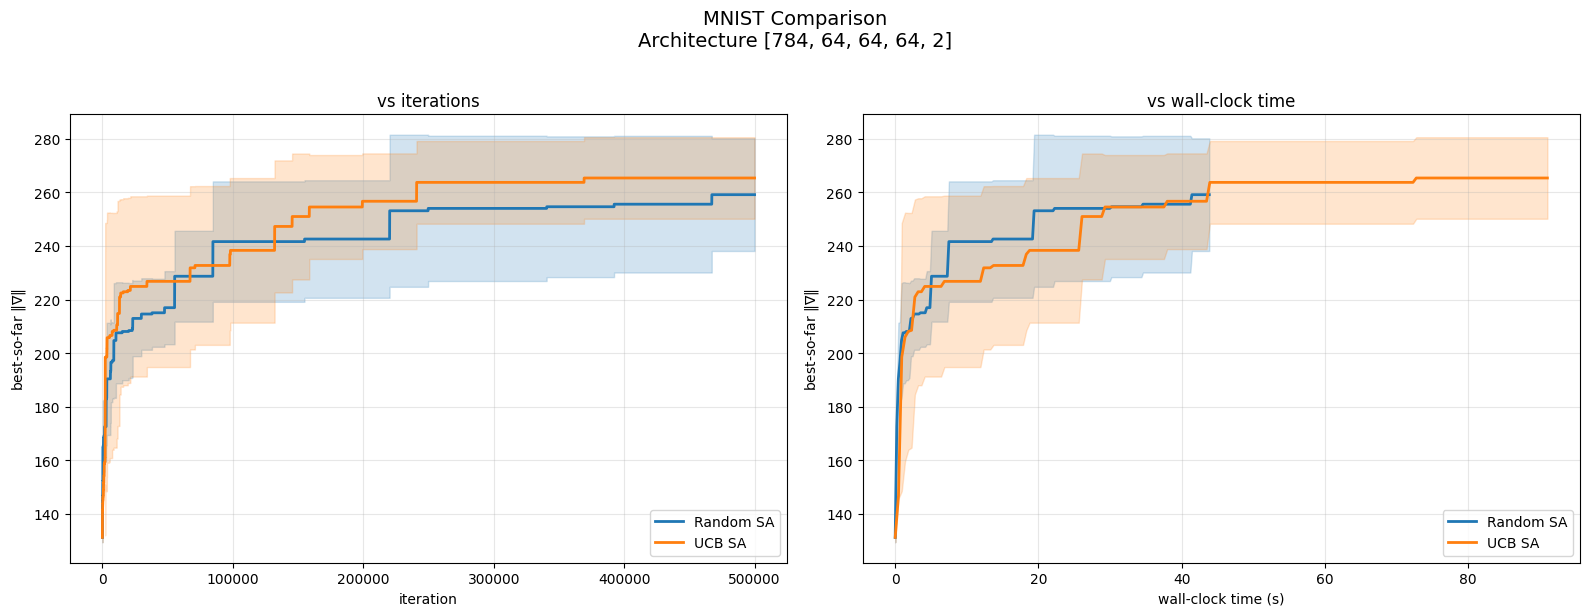

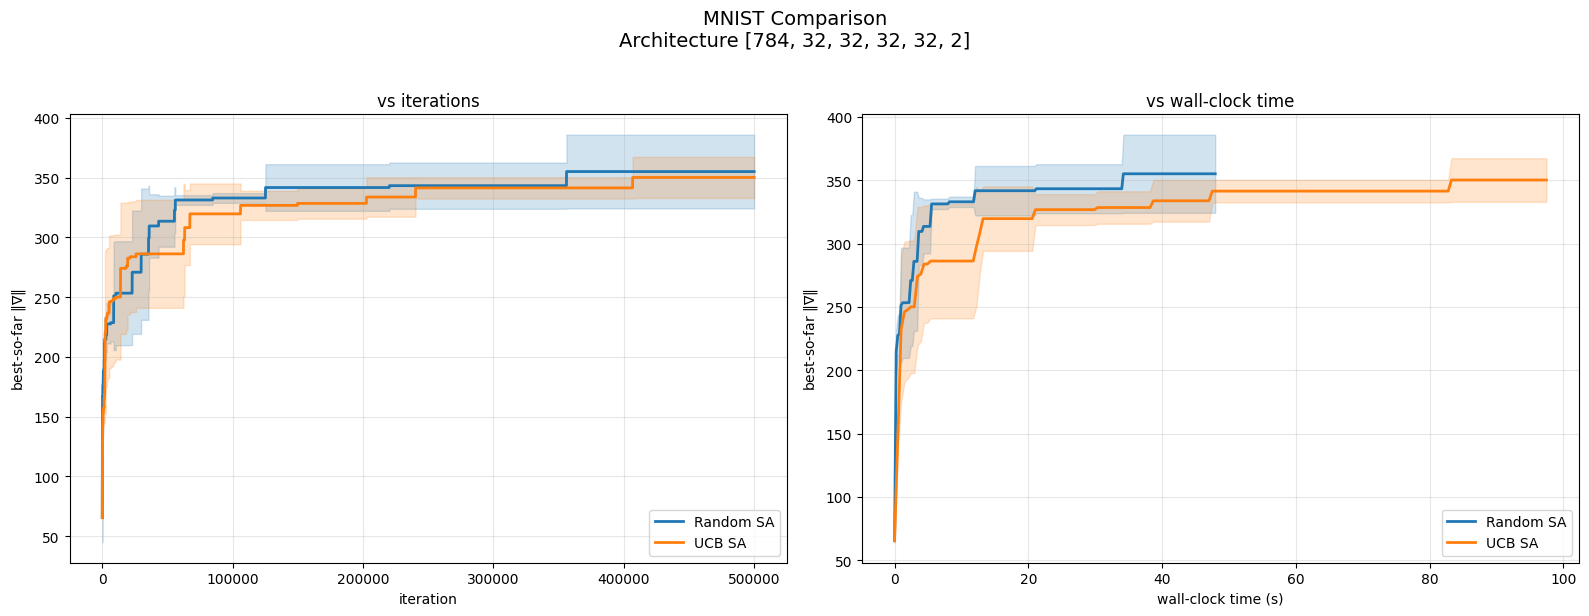

In [23]:
iters = np.arange(1, COMPARE_ITERS + 1)

for arch in ARCHITECTURES:
    r = results[tuple(arch)]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'MNIST Comparison\nArchitecture {arch}', fontsize=14, y=1.02)

    # --- vs iterations ---
    ax = axes[0]
    for label, key, color in [('Random SA', 'rand', 'tab:blue'), ('UCB SA', 'ucb', 'tab:orange')]:
        m, s = r[key]['iter_mean'], r[key]['iter_std']
        ax.plot(iters, m, label=label, color=color, linewidth=2)
        ax.fill_between(iters, m - s, m + s, color=color, alpha=0.2)
    ax.set_xlabel('iteration')
    ax.set_ylabel(r'best-so-far $\|\nabla\|$')
    ax.set_title('vs iterations')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    # --- vs wall-clock time ---
    ax = axes[1]
    for label, key, color in [('Random SA', 'rand', 'tab:blue'), ('UCB SA', 'ucb', 'tab:orange')]:
        g, m, s = r[key]['time_grid'], r[key]['time_mean'], r[key]['time_std']
        ax.plot(g, m, label=label, color=color, linewidth=2)
        ax.fill_between(g, m - s, m + s, color=color, alpha=0.2)
    ax.set_xlabel('wall-clock time (s)')
    ax.set_ylabel(r'best-so-far $\|\nabla\|$')
    ax.set_title('vs wall-clock time')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Summary table

In [22]:
def fmt_meanstd(arr, unit='', precision=4):
    return f"{arr.mean():.{precision}f} ± {arr.std():.{precision}f}{unit}"


header = (f"{'arch':<28} {'method':>8} "
          f"{'final value':>22} {'total time':>20}")
print(header); print('-' * len(header))

for arch in ARCHITECTURES:
    r = results[tuple(arch)]
    for method, label in [('rand', 'random'), ('ucb', 'ucb')]:
        finals = np.array([h[-1] for h in r[method]['v_hist']])
        times  = np.array([t[-1] for t in r[method]['t_hist']])
        prefix_arch = str(arch) if method == 'rand' else ''
        print(f"{prefix_arch:<28} {label:>8} "
              f"{fmt_meanstd(finals, '', 4):>22} "
              f"{fmt_meanstd(times, ' s', 2):>20}")

arch                           method            final value           total time
---------------------------------------------------------------------------------
[784, 32, 32, 2]               random      311.5571 ± 6.3033       37.14 ± 0.17 s
                                  ucb      314.7088 ± 0.0000       89.52 ± 2.11 s
[784, 64, 64, 64, 2]           random     259.1614 ± 21.0287       44.01 ± 0.12 s
                                  ucb     265.3880 ± 15.2161       95.52 ± 2.97 s
[784, 32, 32, 32, 32, 2]       random     355.0857 ± 30.8449       48.16 ± 0.25 s
                                  ucb     350.1665 ± 17.2058      101.41 ± 2.41 s
